<a href="https://colab.research.google.com/github/ihsanhkurniawan/2206130-TugasIhsan/blob/main/PROJEK_SAMPAH_INFEKSIUS_COMPUTER_VISION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.7 MB/s eta 0:00:00


In [ ]:
!apt-get -qq install -y graphviz && pip install pydot
import pydot

In [ ]:
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=9e4fa329c59a39f512f1b22705f40eea799617833ea0acead7a03b233b7d2108
  Stored in directory: /root/.cache/pip/wheels/29/20/ab/f101da7b245b996aa097685ef742243725ea6150f5b3b6d9ed
Successfully built libarchive


In [ ]:
!apt-get -qq install -y libfluidsynth1

E: Package 'libfluidsynth1' has no installation candidate


In [ ]:
!pip install matplotlib-venn

In [ ]:
!pip install split-folders

In [ ]:
import os
import zipfile
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os, shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from sklearn.model_selection import train_test_split
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, shutil
from sklearn.model_selection import train_test_split

# Path ke data awal
source_dir = '/content/drive/MyDrive/Machine Learning/Medical Waste 4.0'

# Hanya ambil yang berupa folder
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# Target folder
base_dir = 'data_split'
os.makedirs(base_dir, exist_ok=True)

for class_name in classes:
    img_dir = os.path.join(source_dir, class_name)
    images = os.listdir(img_dir)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split, img_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        target_dir = os.path.join(base_dir, split, class_name)
        os.makedirs(target_dir, exist_ok=True)
        for img in img_list:
            shutil.copy(os.path.join(img_dir, img), os.path.join(target_dir, img))


In [ ]:
# Folder asal dan tujuan
source_base = '/content/drive/MyDrive/Machine Learning/Medical Waste 4.0'
target_base = '/content/augmented_glove_dataset'

In [ ]:
# Daftar kelas glove
glove_classes = [
    'glove_pair_latex',
    'glove_pair_nitrile',
    'glove_pair_surgery',
    'glove_single_latex',
    'glove_single_nitrile',
    'glove_single_surgery'
]


In [ ]:
# Augmentasi khusus untuk glove
glove_aug = ImageDataGenerator(
    rotation_range=40,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Untuk setiap kelas glove
for class_name in glove_classes:
    source_folder = os.path.join(source_base, class_name)
    target_folder = os.path.join(target_base, class_name)
    os.makedirs(target_folder, exist_ok=True)

    print(f"Augmenting: {class_name}")

Augmenting: glove_pair_latex
Augmenting: glove_pair_nitrile
Augmenting: glove_pair_surgery
Augmenting: glove_single_latex
Augmenting: glove_single_nitrile
Augmenting: glove_single_surgery


In [ ]:
# Ambil semua file gambar dari folder
for fname in tqdm(os.listdir(source_folder)):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(source_folder, fname)
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        # Simpan 5 augmentasi per gambar
        prefix = os.path.splitext(fname)[0]
        i = 0
        for batch in glove_aug.flow(x, batch_size=1,
                                     save_to_dir=target_folder,
                                     save_prefix=prefix,
                                     save_format='jpg'):
            i += 1
            if i >= 5:
                break

100%|██████████| 306/306 [00:34<00:00,  9.00it/s]


In [ ]:
#IMAGE DATA GENERATOR

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Untuk data training dengan augmentasi
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # dari ResNet50
    rotation_range=30,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

# Untuk data validasi & testing (tanpa augmentasi)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load data training
train_data = train_datagen.flow_from_directory(
    'data_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load data validasi
val_data = val_test_datagen.flow_from_directory(
    'data_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load data testing
test_data = val_test_datagen.flow_from_directory(
    'data_split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # penting agar evaluasi dan confusion matrix akurat
)


Found 2969 images belonging to 13 classes.
Found 636 images belonging to 13 classes.
Found 640 images belonging to 13 classes.


In [ ]:
# Load base model MobileNetV2 tanpa top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze semua layer pada base model agar tidak ikut dilatih
base_model.trainable = False

# Tambahkan custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

# Gabungkan base model + classifier
model_mobilenetv2 = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model_mobilenetv2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan struktur model
model_mobilenetv2.summary()

# Setup callback untuk early stopping dan model checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_mobilenetv2.h5', monitor='val_accuracy', save_best_only=True)

# Train model
history_mobilenetv2 = model_mobilenetv2.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

# Evaluasi pada data test
test_loss, test_acc = model_mobilenetv2.evaluate(test_data)
print(f'\nTest Accuracy: {test_acc:.4f}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,629 (9.25 MB)

 Trainable params: 165,645 (647.05 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7186 - loss: 0.7800 - val_accuracy: 0.7783 - val_loss: 0.6063
Epoch 18/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7241 - loss: 0.7740

93/93 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.7241 - loss: 0.7739 - val_accuracy: 0.7862 - val_loss: 0.5787
Epoch 19/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7363 - loss: 0.7356 - val_accuracy: 0.7799 - val_loss: 0.5741
Epoch 20/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.7389 - loss: 0.7036 - val_accuracy: 0.7783 - val_loss: 0.5602
Epoch 21/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.7395 - loss: 0.6997 - val_accuracy: 0.7862 - val_loss: 0.5547
Epoch 22/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7407 - loss: 0.6609

93/93 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.7407 - loss: 0.6609 - val_accuracy: 0.8082 - val_loss: 0.5218
Epoch 23/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7606 - loss: 0.6575

93/93 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.7607 - loss: 0.6573 - val_accuracy: 0.8097 - val_loss: 0.5133
Epoch 24/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.7546 - loss: 0.6689 - val_accuracy: 0.7972 - val_loss: 0.5175
Epoch 25/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.7562 - loss: 0.6488 - val_accuracy: 0.8003 - val_loss: 0.5029
Epoch 26/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7729 - loss: 0.6089

93/93 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7728 - loss: 0.6090 - val_accuracy: 0.8145 - val_loss: 0.4960
Epoch 27/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.7864 - loss: 0.5986 - val_accuracy: 0.8019 - val_loss: 0.4922
Epoch 28/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7691 - loss: 0.6162 - val_accuracy: 0.8097 - val_loss: 0.4836
Epoch 29/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.7813 - loss: 0.5861 - val_accuracy: 0.8097 - val_loss: 0.4988
Epoch 30/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7614 - loss: 0.6210 - val_accuracy: 0.8003 - val_loss: 0.4925
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7552 - loss: 0.5625

Test Accuracy: 0.7984


In [ ]:
# MODEL RESNET50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze semua layer
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(13, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,614,349 (90.08 MB)

 Trainable params: 26,637 (104.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
#  TRAINING R---
history = model.fit(
    train_data,
    validation_data   = val_data,
    epochs            = 30,
    steps_per_epoch   = len(train_data),   # aman:  ≈ total_batch
    validation_steps  = len(val_data)
)


Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 645s 7s/step - accuracy: 0.3376 - loss: 2.2260 - val_accuracy: 0.7657 - val_loss: 0.6054
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 633s 7s/step - accuracy: 0.7423 - loss: 0.6702 - val_accuracy: 0.8601 - val_loss: 0.3890
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 679s 7s/step - accuracy: 0.8104 - loss: 0.5174 - val_accuracy: 0.8522 - val_loss: 0.3786
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 692s 7s/step - accuracy: 0.8439 - loss: 0.4097 - val_accuracy: 0.8695 - val_loss: 0.3385
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 678s 7s/step - accuracy: 0.8565 - loss: 0.3628 - val_accuracy: 0.8962 - val_loss: 0.2756
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 695s 7s/step - accuracy: 0.8709 - loss: 0.3206 - val_accuracy: 0.8852 - val_loss: 0.3342
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 636s 7s/step - accuracy: 0.8926 - loss: 0.2879 - val_accuracy: 0.9041 - val_loss: 0.2681
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 679s 7s/step - accuracy: 0.8887 - loss: 0.2713 - val_accuracy: 0.9025 - v

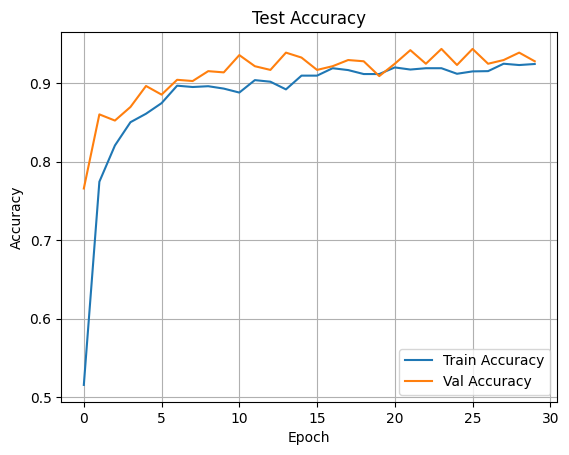

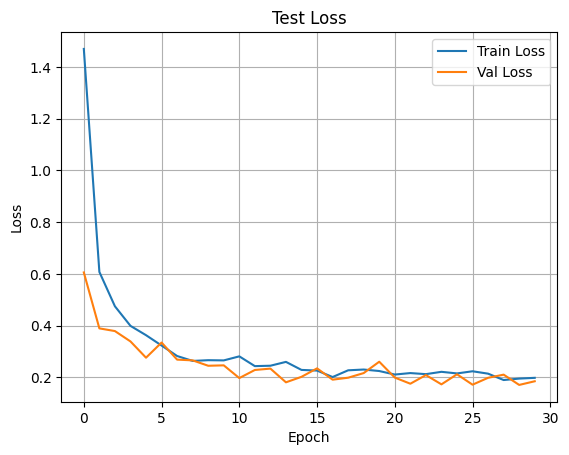

In [ ]:
# Plot akurasi
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

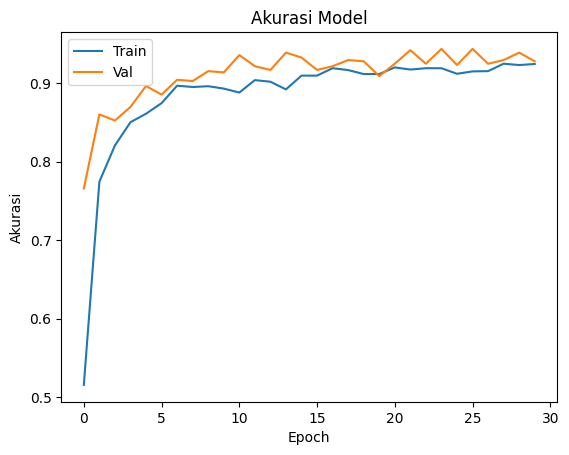

In [ ]:
# ===============================
#  GRAFIK AKURASI
# ===============================
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Akurasi Model')
plt.ylabel('Akurasi')
plt.xlabel('Epoch')
plt.legend()
plt.show()

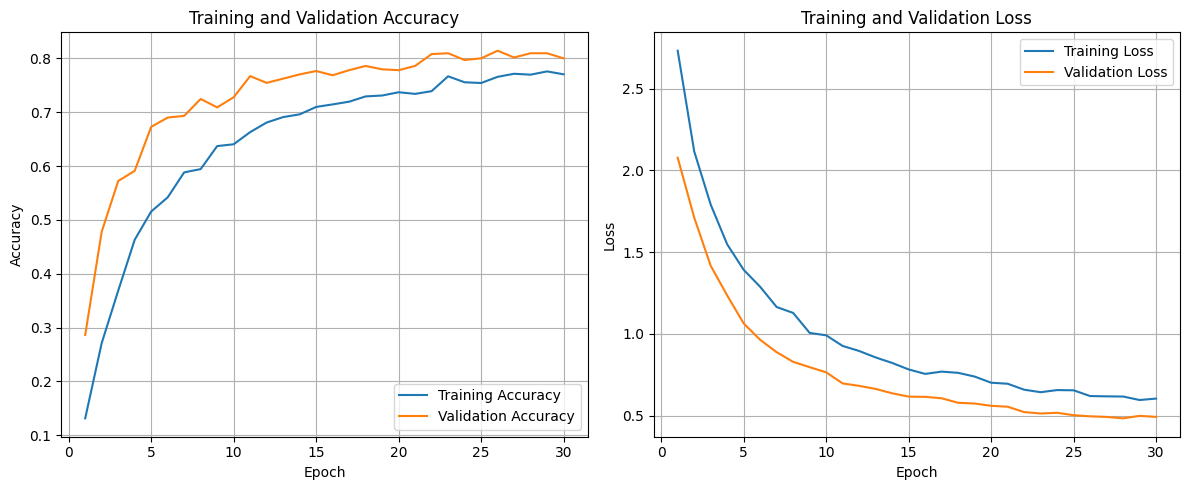

In [ ]:
import matplotlib.pyplot as plt

# Ambil nilai akurasi dan loss dari history
acc = history_mobilenetv2.history['accuracy']
val_acc = history_mobilenetv2.history['val_accuracy']
loss = history_mobilenetv2.history['loss']
val_loss = history_mobilenetv2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Prediksi label dari data test
y_pred_probs = model_mobilenetv2.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Ambil label asli
y_true = test_data.classes


20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step


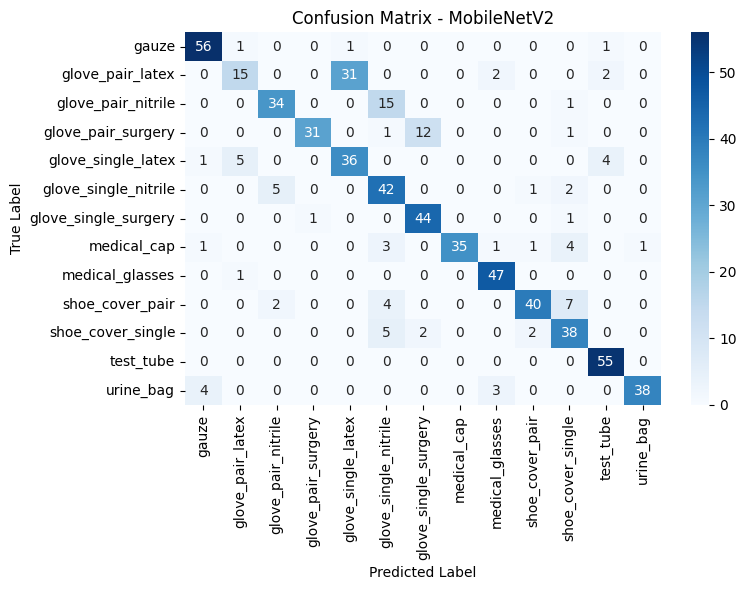

Classification Report:
                       precision    recall  f1-score   support

               gauze       0.90      0.95      0.93        59
    glove_pair_latex       0.68      0.30      0.42        50
  glove_pair_nitrile       0.83      0.68      0.75        50
  glove_pair_surgery       0.97      0.69      0.81        45
  glove_single_latex       0.53      0.78      0.63        46
glove_single_nitrile       0.60      0.84      0.70        50
glove_single_surgery       0.76      0.96      0.85        46
         medical_cap       1.00      0.76      0.86        46
     medical_glasses       0.89      0.98      0.93        48
     shoe_cover_pair       0.91      0.75      0.82        53
   shoe_cover_single       0.70      0.81      0.75        47
           test_tube       0.89      1.00      0.94        55
           urine_bag       0.97      0.84      0.90        45

            accuracy                           0.80       640
           macro avg       0.82      0.80   

In [ ]:
# Nama kelas
class_names = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Laporan klasifikasi
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)


20/20 ━━━━━━━━━━━━━━━━━━━━ 110s 5s/step


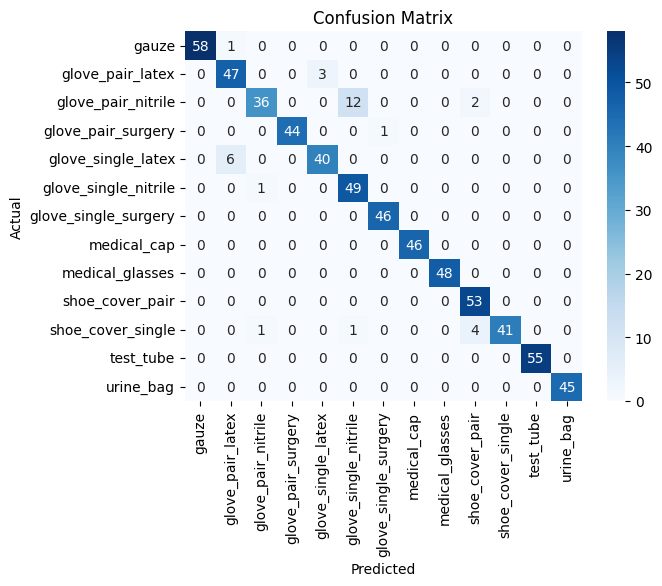


📊 Classification Report:

                      precision    recall  f1-score   support

               gauze       1.00      0.98      0.99        59
    glove_pair_latex       0.87      0.94      0.90        50
  glove_pair_nitrile       0.95      0.72      0.82        50
  glove_pair_surgery       1.00      0.98      0.99        45
  glove_single_latex       0.93      0.87      0.90        46
glove_single_nitrile       0.79      0.98      0.88        50
glove_single_surgery       0.98      1.00      0.99        46
         medical_cap       1.00      1.00      1.00        46
     medical_glasses       1.00      1.00      1.00        48
     shoe_cover_pair       0.90      1.00      0.95        53
   shoe_cover_single       1.00      0.87      0.93        47
           test_tube       1.00      1.00      1.00        55
           urine_bag       1.00      1.00      1.00        45

            accuracy                           0.95       640
           macro avg       0.96      0.95

In [ ]:
# CONFUSION MATRIX
# ===============================
preds = model.predict(test_data)
pred_labels = np.argmax(preds, axis=1)
true_labels = test_data.classes

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices,
            yticklabels=test_data.class_indices)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\n📊 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=test_data.class_indices.keys()))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Melakukan prediksi pada data pengujian...
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
AUC untuk Kelas 0 (gauze): 0.9984
AUC untuk Kelas 1 (glove_pair_latex): 0.9689
AUC untuk Kelas 2 (glove_pair_nitrile): 0.9819
AUC untuk Kelas 3 (glove_pair_surgery): 0.9941
AUC untuk Kelas 4 (glove_single_latex): 0.9697
AUC untuk Kelas 5 (glove_single_nitrile): 0.9804
AUC untuk Kelas 6 (glove_single_surgery): 0.9945
AUC untuk Kelas 7 (medical_cap): 0.9973
AUC untuk Kelas 8 (medical_glasses): 0.9991
AUC untuk Kelas 9 (shoe_cover_pair): 0.9951
AUC untuk Kelas 10 (shoe_cover_single): 0.9871
AUC untuk Kelas 11 (test_tube): 0.9997
AUC untuk Kelas 12 (urine_bag): 0.9992


/tmp/ipython-input-1259789883.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv') # Pilih colormap


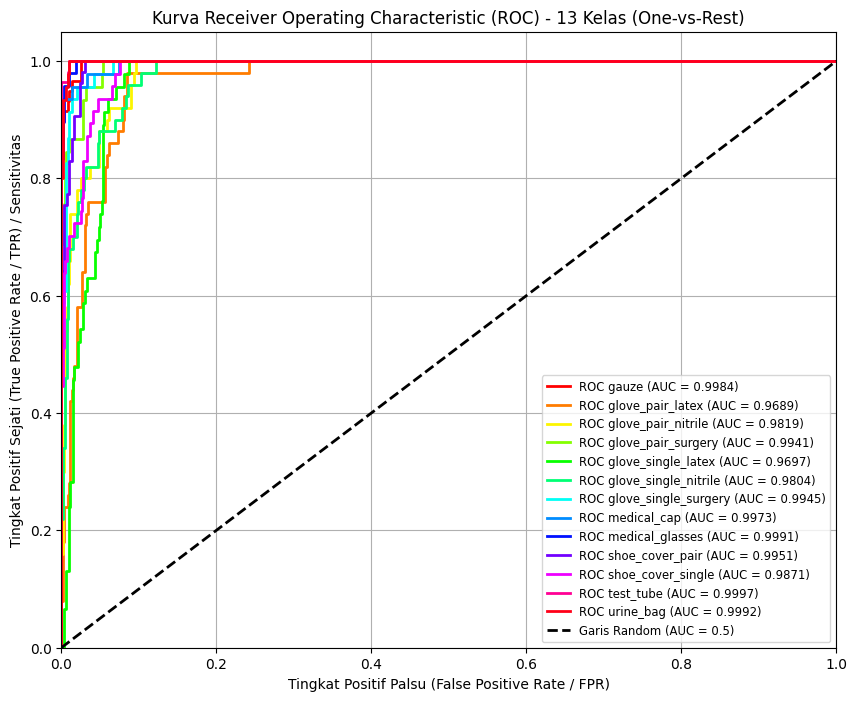


Macro-Average AUC: 0.9899


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical
# Catatan: Pastikan model_mobilenetv2 dan test_data sudah didefinisikan/dimuat di sel sebelumnya!


# --- 1. Mendapatkan Label Sejati dan Probabilitas Prediksi ---
print("Melakukan prediksi pada data pengujian...")
y_pred_proba = model_mobilenetv2.predict(test_data, verbose=1)

y_true_int = test_data.classes
n_classes = test_data.num_classes
y_true_binarized = to_categorical(y_true_int, num_classes=n_classes)

# Mendapatkan nama kelas
idx_to_class = {v: k for k, v in test_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(n_classes)]


# --- 2. Menghitung Kurva ROC (One-vs-Rest) ---
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Hitung Kurva ROC untuk Kelas i melawan Semua Kelas Lain (One-vs-Rest)
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"AUC untuk Kelas {i} ({class_names[i]}): {roc_auc[i]:.4f}")

# --- 3. Plotting Kurva ROC ---

plt.figure(figsize=(10, 8))

# PERBAIKAN UNTUK MENGAMBIL DAFTAR WARNA
cmap = plt.cm.get_cmap('hsv') # Pilih colormap
colors = [cmap(i) for i in np.linspace(0, 1, n_classes)] # Ambil n_classes warna secara merata

# Plot ROC untuk setiap kelas
for i, color in zip(range(n_classes), colors): # Menggunakan list colors yang sudah diperbaiki
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')

# Plot garis diagonal (model random)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Garis Random (AUC = 0.5)')


# Mengatur batas dan label plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tingkat Positif Palsu (False Positive Rate / FPR)')
plt.ylabel('Tingkat Positif Sejati (True Positive Rate / TPR) / Sensitivitas')
plt.title(f'Kurva Receiver Operating Characteristic (ROC) - {n_classes} Kelas (One-vs-Rest)')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.show()

# --- 4. Menghitung Macro-Average AUC ---
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_roc_auc_score = auc(all_fpr, mean_tpr)

print(f"\nMacro-Average AUC: {macro_roc_auc_score:.4f}")

In [9]:
from google.colab import files

# Catatan: Jika variabel model Anda BUKAN bernama 'model'
# (misalnya bernama 'cnn_model' atau 'klasifikasi'),
# ubah kata 'model' di baris bawah ini sesuai dengan nama variabel Anda.

model.save('PROJEK SAMPAH INFEKSIUS COMPUTER VISION.IPYNB_.h5')
files.download('PROJEK SAMPAH INFEKSIUS COMPUTER VISION.IPYNB_.h5')

NameError: name 'model' is not defined